# Network Robustness Analysis — Bitcoin-OTC Trust Network

## Research Question
> **How robust is the Bitcoin-OTC trust network to the removal of highly influential nodes, and does its structural collapse depend more on high-degree hubs or on high-reputation nodes?**

### Methodology Overview

We evaluate **network robustness** under three targeted attack strategies:

| Strategy | Node ranking criterion |
|---|---|
| **High-Degree Attack** | Total degree (in + out) — structural hubs |
| **High-Reputation Attack** | Mean received rating — most-trusted nodes |
| **Random Removal** | Uniform random — baseline for comparison |

At each step we remove a fraction of nodes and measure:
- **Relative LCC size** $S = |LCC| / N_0$ — how much of the network stays connected
- **Number of connected components** — fragmentation level
- **Average shortest path length** (on LCC undirected) — communication efficiency
- **Average clustering coefficient** — local cohesion

We also compute the **robustness integral** $R = \sum S(f) \cdot \Delta f$ as a single scalar summary.

---
## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Reproducibility
SEED = 42
np.random.seed(SEED)

# Aesthetic settings
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# Attack strategy colors and labels
STRATEGIES = {
    'degree':     {'color': '#e74c3c', 'label': 'High-Degree Attack',     'ls': '-'},
    'reputation': {'color': '#2980b9', 'label': 'High-Reputation Attack', 'ls': '--'},
    'random':     {'color': '#27ae60', 'label': 'Random Removal',          'ls': ':'},
}

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Load and Inspect the Dataset

In [19]:
DATA_PATH = '/content/drive/MyDrive/MO412_Project_v2/soc-sign-bitcoinotc.csv'

df = pd.read_csv(DATA_PATH)
df.columns = ['source', 'target', 'rating', 'time']

print(f"Dataset shape : {df.shape}")
print(f"Rating range  : [{df['rating'].min()}, {df['rating'].max()}]")
print(f"Unique sources: {df['source'].nunique()}")
print(f"Unique targets: {df['target'].nunique()}")
print()
df.head()

Dataset shape : (35592, 4)
Rating range  : [-10, 10]
Unique sources: 4814
Unique targets: 5858



,source,target,rating,time
0,6,2,4,1.289242e+09
1,6,5,2,1.289242e+09
2,1,15,1,1.289243e+09
3,4,3,7,1.289245e+09
4,13,16,8,1.289254e+09


---
## 3. Build the Full Directed Graph

In [5]:
G_dir = nx.from_pandas_edgelist(
    df, source='source', target='target',
    edge_attr=['rating', 'time'],
    create_using=nx.DiGraph()
)

N0 = G_dir.number_of_nodes()
L0 = G_dir.number_of_edges()

print(f"Nodes  : {N0}")
print(f"Edges  : {L0}")
print(f"Density: {nx.density(G_dir):.6f}")

# Largest Weakly Connected Component (LWCC) — used as analysis base
lwcc_nodes = max(nx.weakly_connected_components(G_dir), key=len)
G_lwcc = G_dir.subgraph(lwcc_nodes).copy()
print(f"\nLargest WCC: {G_lwcc.number_of_nodes()} nodes "
      f"({100*G_lwcc.number_of_nodes()/N0:.1f}% of total)")

Nodes  : 5881
Edges  : 35592
Density: 0.001029

Largest WCC: 5875 nodes (99.9% of total)


---
## 4. Compute Node Influence Scores

Two influence dimensions are computed for every node:

- **Degree** = in-degree + out-degree (structural centrality)
- **Reputation** = mean rating received from all raters (trust centrality)

In [20]:
# Degree score
degree_scores = dict(G_dir.degree())   # total (in + out)

# Reputation score: mean rating received
received_ratings = defaultdict(list)
for _, row in df.iterrows():
    received_ratings[row['target']].append(row['rating'])

# Nodes with no incoming edges get reputation = 0
reputation_scores = {
    node: np.mean(received_ratings[node]) if node in received_ratings else 0.0
    for node in G_dir.nodes()
}

# Summary statistics
deg_vals = np.array(list(degree_scores.values()))
rep_vals = np.array(list(reputation_scores.values()))

print(f"Degree     — mean: {deg_vals.mean():.2f}, max: {deg_vals.max()}, "
      f"median: {np.median(deg_vals):.1f}")
print(f"Reputation — mean: {rep_vals.mean():.2f}, max: {rep_vals.max():.2f}, "
      f"min: {rep_vals.min():.2f}")

Degree     — mean: 12.10, max: 1298, median: 4.0
Reputation — mean: 0.73, max: 10.00, min: -10.00


Pearson correlation (degree vs reputation): 0.0433


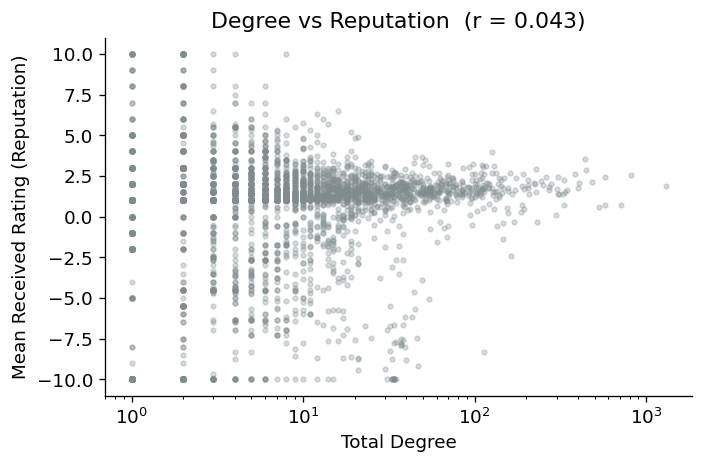

In [21]:
# Joint distribution: are high-degree nodes also high-reputation?
common_nodes = list(G_dir.nodes())
deg_arr = np.array([degree_scores[n] for n in common_nodes])
rep_arr = np.array([reputation_scores[n] for n in common_nodes])

corr = np.corrcoef(deg_arr, rep_arr)[0, 1]
print(f"Pearson correlation (degree vs reputation): {corr:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(deg_arr, rep_arr, alpha=0.3, s=8, color='#7f8c8d')
ax.set_xlabel('Total Degree')
ax.set_ylabel('Mean Received Rating (Reputation)')
ax.set_title(f'Degree vs Reputation  (r = {corr:.3f})')
ax.set_xscale('log')
plt.tight_layout()
plt.show()

---
## 5. Robustness Simulation

We iteratively remove nodes ranked by each strategy and record structural metrics after each removal step.

> **Working graph**: we use the full directed graph converted to **undirected** for LCC tracking (standard in robustness literature), consistent with the pre-analysis approach using the largest WCC.

In [22]:
def compute_metrics(G_und, N0):
    """Return a dict of robustness metrics for the current graph state."""
    if G_und.number_of_nodes() == 0:
        return {'lcc_rel': 0.0, 'n_components': 0, 'avg_path': np.nan, 'avg_clust': np.nan}

    components = list(nx.connected_components(G_und))
    lcc = max(components, key=len)
    lcc_rel = len(lcc) / N0

    G_lcc = G_und.subgraph(lcc).copy()

    # Average shortest path — expensive; sample if LCC is large
    if len(lcc) <= 500:
        try:
            avg_path = nx.average_shortest_path_length(G_lcc)
        except Exception:
            avg_path = np.nan
    else:
        # Approximate via BFS from 200 random sources
        sources = np.random.choice(list(G_lcc.nodes()), size=min(200, len(lcc)), replace=False)
        lengths = []
        for s in sources:
            sp = nx.single_source_shortest_path_length(G_lcc, s)
            lengths.extend(sp.values())
        avg_path = np.mean(lengths) if lengths else np.nan

    avg_clust = nx.average_clustering(G_lcc)

    return {
        'lcc_rel':      lcc_rel,
        'n_components': len(components),
        'avg_path':     avg_path,
        'avg_clust':    avg_clust,
    }


def simulate_attack(G_dir, scores_dict, n_steps=50, seed=SEED):
    """
    Remove nodes in descending order of `scores_dict`.
    Returns a DataFrame with metrics at each removal fraction.
    """
    rng = np.random.default_rng(seed)
    G_und = G_dir.to_undirected()
    N0    = G_und.number_of_nodes()

    # Sort nodes by score (descending)
    sorted_nodes = sorted(scores_dict.keys(),
                          key=lambda n: scores_dict.get(n, 0),
                          reverse=True)

    step_size  = max(1, N0 // n_steps)
    checkpoints = list(range(0, N0, step_size)) + [N0]

    records = []
    G_cur   = G_und.copy()
    removed = 0

    for ck in checkpoints:
        while removed < ck:
            node = sorted_nodes[removed]
            if G_cur.has_node(node):
                G_cur.remove_node(node)
            removed += 1

        metrics = compute_metrics(G_cur, N0)
        metrics['fraction_removed'] = removed / N0
        records.append(metrics)

    return pd.DataFrame(records)


def simulate_random(G_dir, n_steps=50, n_runs=5, seed=SEED):
    """
    Random removal: average over `n_runs` independent runs.
    """
    rng    = np.random.default_rng(seed)
    G_und  = G_dir.to_undirected()
    N0     = G_und.number_of_nodes()
    all_runs = []

    for run in range(n_runs):
        node_order = list(G_und.nodes())
        rng.shuffle(node_order)
        # Build a fake scores dict using the shuffled order
        shuffled_scores = {n: (N0 - i) for i, n in enumerate(node_order)}
        df_run = simulate_attack(G_dir, shuffled_scores, n_steps=n_steps)
        all_runs.append(df_run)

    # Average across runs
    combined = pd.concat(all_runs)
    return combined.groupby('fraction_removed').mean().reset_index()


print('Simulation functions defined.')
print('Running simulations — this may take a minute...')

Simulation functions defined.
Running simulations — this may take a minute...


In [23]:
N_STEPS = 60   # number of checkpoints (granularity vs speed trade-off)

print('► Degree-based attack...')
results_degree = simulate_attack(G_dir, degree_scores, n_steps=N_STEPS)

print('► Reputation-based attack...')
results_rep    = simulate_attack(G_dir, reputation_scores, n_steps=N_STEPS)

print('► Random removal (5 runs)...')
results_random = simulate_random(G_dir, n_steps=N_STEPS, n_runs=5)

print('Done!')

all_results = {
    'degree':     results_degree,
    'reputation': results_rep,
    'random':     results_random,
}

► Degree-based attack...
► Reputation-based attack...
► Random removal (5 runs)...
Done!


---
## 6. Robustness Integral $R$

$$R = \sum_{q=1/N}^{1} S(q) \cdot \frac{1}{N}$$

where $S(q)$ is the relative LCC size after removing fraction $q$ of nodes. Higher $R$ means a more robust network.

In [24]:
def robustness_integral(df_result):
    """Trapezoidal integration of S(f) over f in [0,1]."""
    f = df_result['fraction_removed'].values
    s = df_result['lcc_rel'].values
    return np.trapz(s, f)

print("Robustness Integrals (R):")
print("-" * 40)
for key, df_r in all_results.items():
    R = robustness_integral(df_r)
    print(f"  {STRATEGIES[key]['label']:30s}: R = {R:.4f}")

Robustness Integrals (R):
----------------------------------------
  High-Degree Attack            : R = 0.0588
  High-Reputation Attack        : R = 0.3343
  Random Removal                : R = 0.4011


---
## 7. Visualization

### 7.1 Relative LCC Size vs Fraction Removed

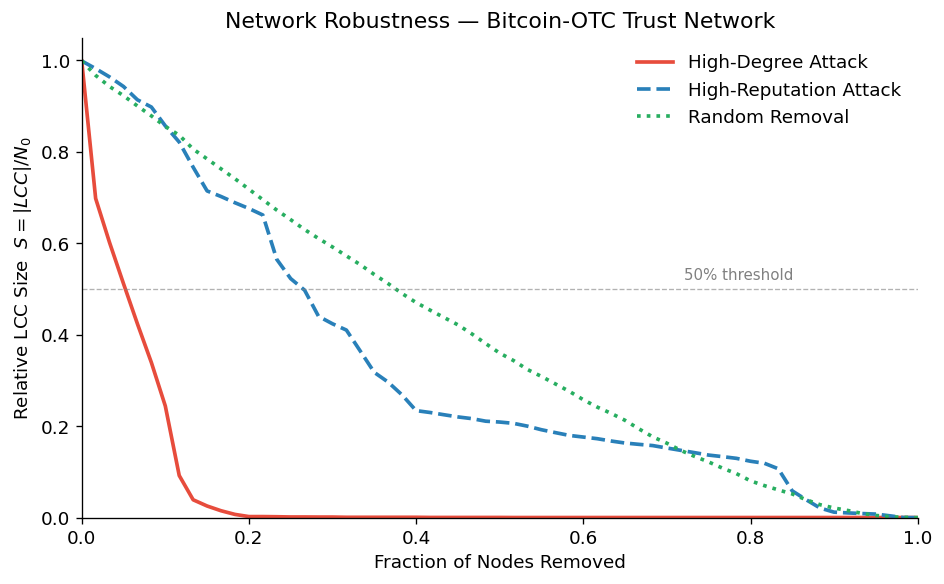

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

for key, df_r in all_results.items():
    s = STRATEGIES[key]
    ax.plot(
        df_r['fraction_removed'],
        df_r['lcc_rel'],
        color=s['color'], linestyle=s['ls'], lw=2.2, label=s['label']
    )

ax.set_xlabel('Fraction of Nodes Removed')
ax.set_ylabel('Relative LCC Size  $S = |LCC|/N_0$')
ax.set_title('Network Robustness — Bitcoin-OTC Trust Network')
ax.legend(frameon=False)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.text(0.72, 0.52, '50% threshold', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig('robustness_lcc.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Number of Connected Components

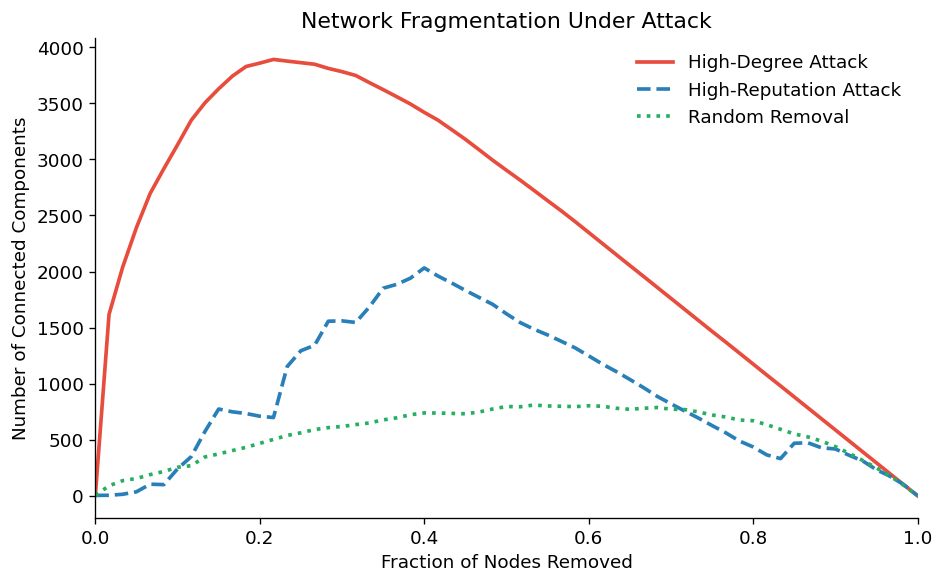

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

for key, df_r in all_results.items():
    s = STRATEGIES[key]
    ax.plot(
        df_r['fraction_removed'],
        df_r['n_components'],
        color=s['color'], linestyle=s['ls'], lw=2.2, label=s['label']
    )

ax.set_xlabel('Fraction of Nodes Removed')
ax.set_ylabel('Number of Connected Components')
ax.set_title('Network Fragmentation Under Attack')
ax.legend(frameon=False)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('robustness_components.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Average Shortest Path Length (LCC)

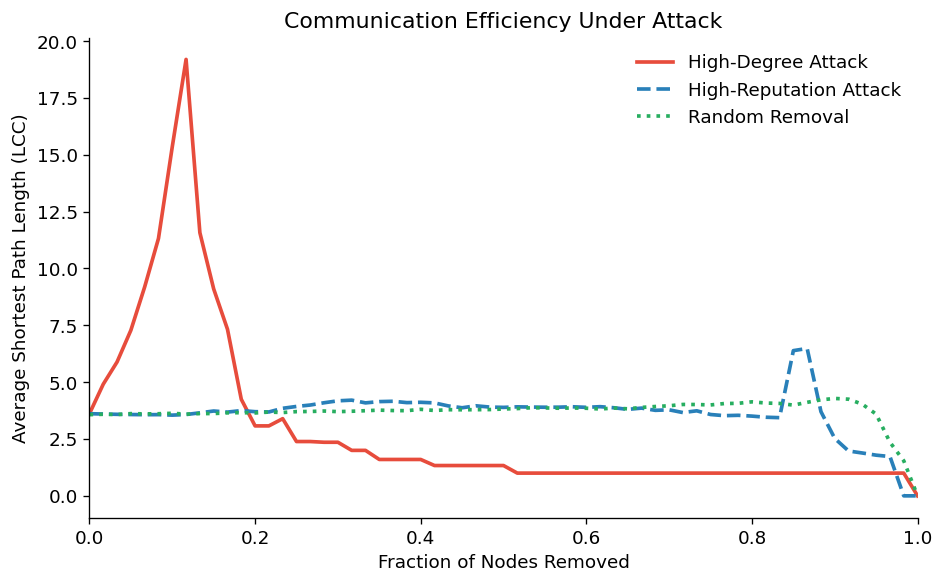

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

for key, df_r in all_results.items():
    s = STRATEGIES[key]
    valid = df_r.dropna(subset=['avg_path'])
    ax.plot(
        valid['fraction_removed'],
        valid['avg_path'],
        color=s['color'], linestyle=s['ls'], lw=2.2, label=s['label']
    )

ax.set_xlabel('Fraction of Nodes Removed')
ax.set_ylabel('Average Shortest Path Length (LCC)')
ax.set_title('Communication Efficiency Under Attack')
ax.legend(frameon=False)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('robustness_path.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 Average Clustering Coefficient (LCC)

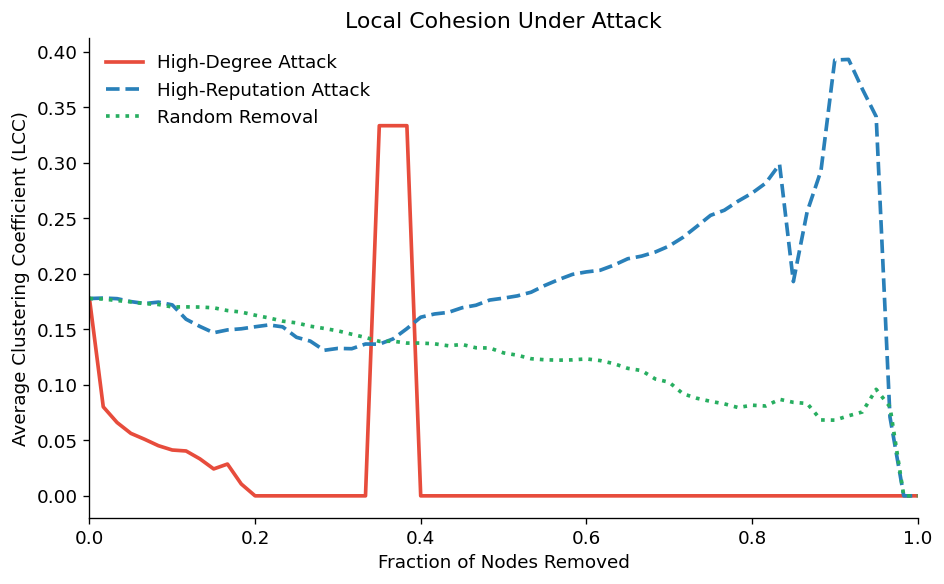

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))

for key, df_r in all_results.items():
    s = STRATEGIES[key]
    valid = df_r.dropna(subset=['avg_clust'])
    ax.plot(
        valid['fraction_removed'],
        valid['avg_clust'],
        color=s['color'], linestyle=s['ls'], lw=2.2, label=s['label']
    )

ax.set_xlabel('Fraction of Nodes Removed')
ax.set_ylabel('Average Clustering Coefficient (LCC)')
ax.set_title('Local Cohesion Under Attack')
ax.legend(frameon=False)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('robustness_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.5 All Metrics — Dashboard

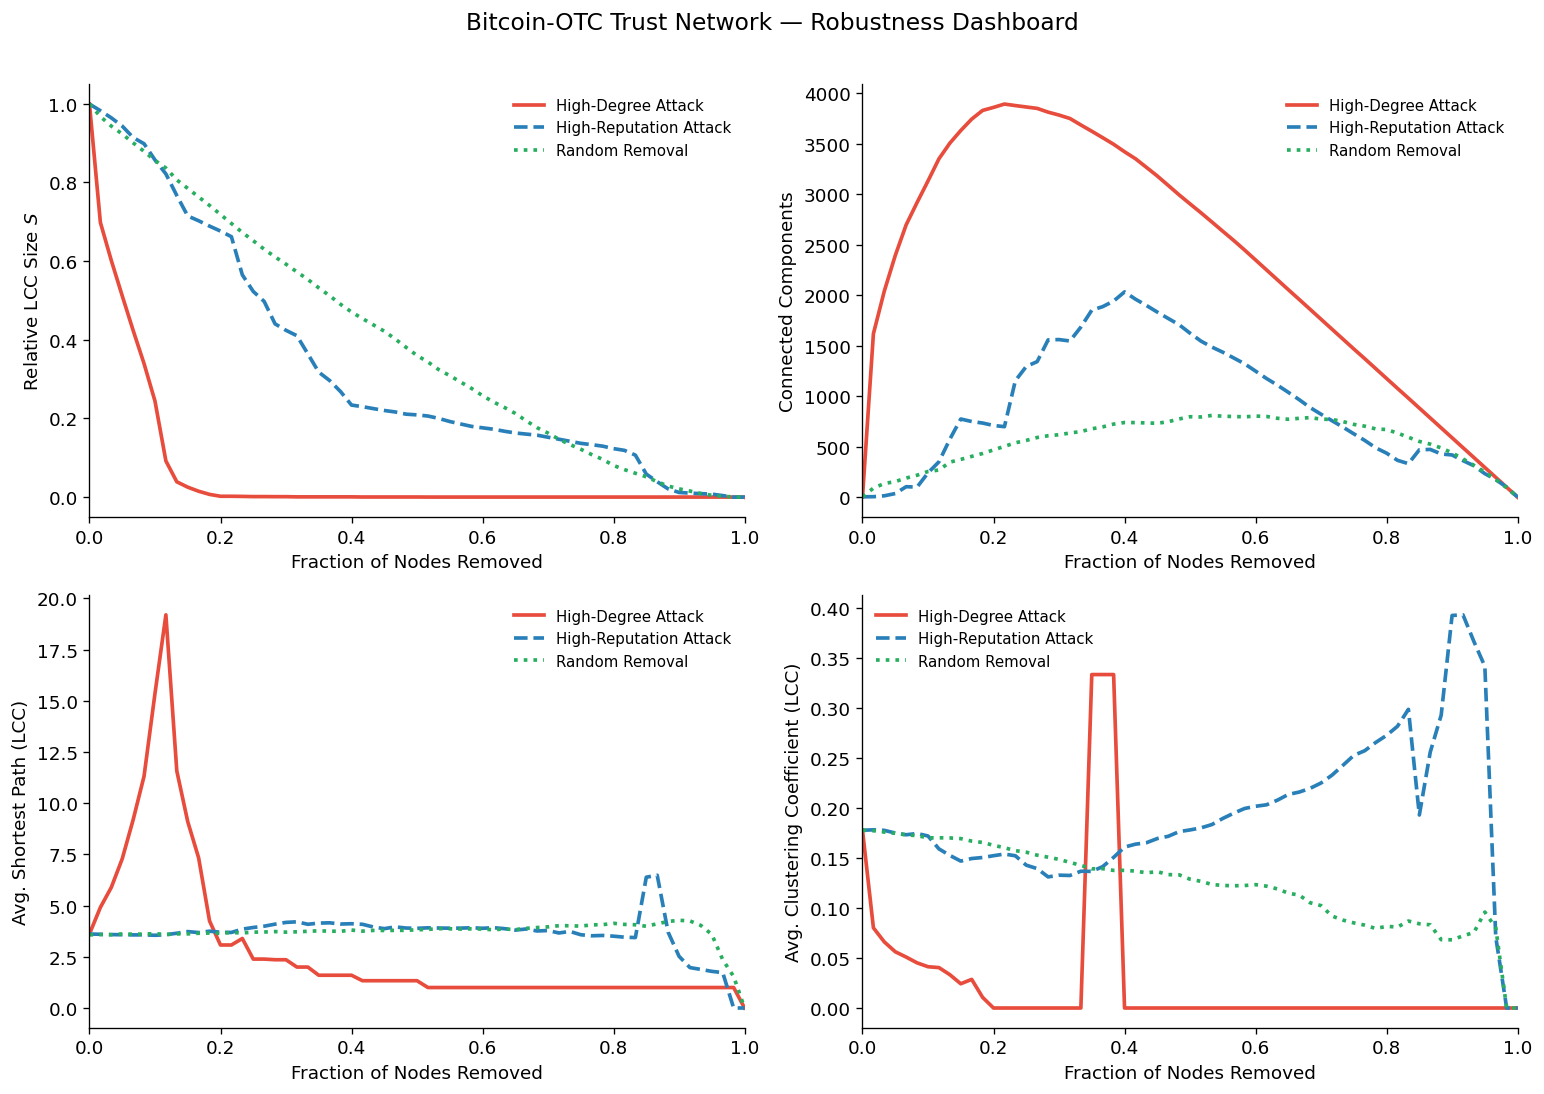

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

metrics = [
    ('lcc_rel',      'Relative LCC Size $S$',              axes[0, 0]),
    ('n_components', 'Connected Components',                axes[0, 1]),
    ('avg_path',     'Avg. Shortest Path (LCC)',            axes[1, 0]),
    ('avg_clust',    'Avg. Clustering Coefficient (LCC)',   axes[1, 1]),
]

for metric, ylabel, ax in metrics:
    for key, df_r in all_results.items():
        s = STRATEGIES[key]
        valid = df_r.dropna(subset=[metric])
        ax.plot(
            valid['fraction_removed'], valid[metric],
            color=s['color'], linestyle=s['ls'], lw=2.2, label=s['label']
        )
    ax.set_xlabel('Fraction of Nodes Removed')
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, 1)
    ax.legend(frameon=False, fontsize=9)

fig.suptitle('Bitcoin-OTC Trust Network — Robustness Dashboard', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('robustness_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Critical Threshold Analysis

Identify $f_c$ — the fraction at which the LCC drops below 50% of its original size.

In [16]:
def find_critical_threshold(df_result, threshold=0.5):
    """Fraction of removed nodes when LCC first drops below `threshold`."""
    below = df_result[df_result['lcc_rel'] < threshold]
    if below.empty:
        return None
    return below['fraction_removed'].iloc[0]

print(f"{'Strategy':35s} {'f_c (LCC < 50%)':20s} {'R (integral)':>12}")
print('-' * 70)
for key, df_r in all_results.items():
    fc  = find_critical_threshold(df_r)
    R   = robustness_integral(df_r)
    fc_str = f"{fc:.3f}" if fc is not None else 'never'
    print(f"{STRATEGIES[key]['label']:35s} {fc_str:20s} {R:>12.4f}")

Strategy                            f_c (LCC < 50%)      R (integral)
----------------------------------------------------------------------
High-Degree Attack                  0.067                      0.0588
High-Reputation Attack              0.267                      0.3343
Random Removal                      0.383                      0.4011


---
## 9. Top Influential Nodes

Who are the nodes whose removal destabilizes the network the most?

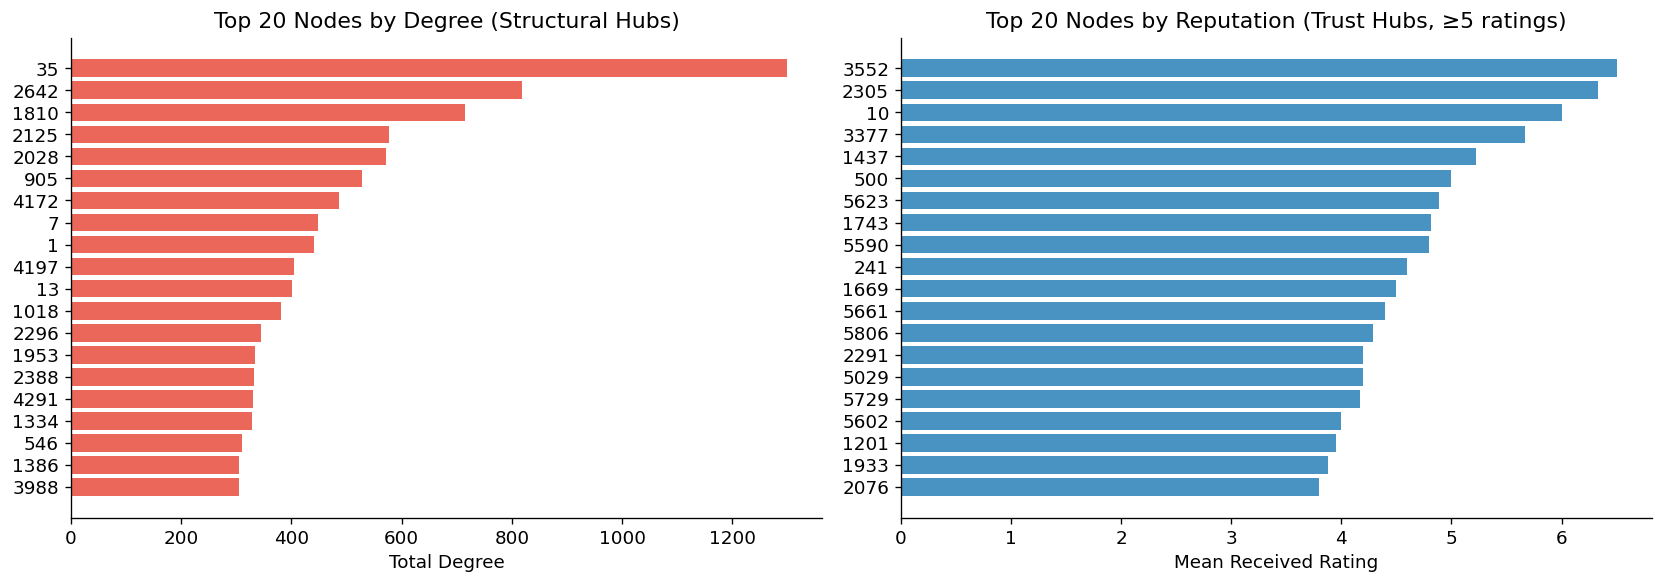


Overlap between top-20 degree and top-20 reputation nodes: 0 node(s)


In [17]:
# Top-20 nodes by degree
top_degree = sorted(degree_scores.items(), key=lambda x: x[1], reverse=True)[:20]

# Top-20 nodes by reputation (min 5 ratings received for significance)
rep_filtered = {
    n: score for n, score in reputation_scores.items()
    if len(received_ratings.get(n, [])) >= 5
}
top_rep = sorted(rep_filtered.items(), key=lambda x: x[1], reverse=True)[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Degree
nodes_d, vals_d = zip(*top_degree)
axes[0].barh([str(n) for n in nodes_d[::-1]], vals_d[::-1],
             color='#e74c3c', alpha=0.85)
axes[0].set_xlabel('Total Degree')
axes[0].set_title('Top 20 Nodes by Degree (Structural Hubs)')

# Reputation
nodes_r, vals_r = zip(*top_rep)
axes[1].barh([str(n) for n in nodes_r[::-1]], vals_r[::-1],
             color='#2980b9', alpha=0.85)
axes[1].set_xlabel('Mean Received Rating')
axes[1].set_title('Top 20 Nodes by Reputation (Trust Hubs, ≥5 ratings)')

plt.tight_layout()
plt.savefig('top_influential_nodes.png', dpi=150, bbox_inches='tight')
plt.show()

# Overlap: how many of the top-20 nodes appear in BOTH lists?
set_d = set(n for n, _ in top_degree)
set_r = set(n for n, _ in top_rep)
overlap = set_d & set_r
print(f"\nOverlap between top-20 degree and top-20 reputation nodes: {len(overlap)} node(s)")
if overlap:
    print(f"  Shared nodes: {overlap}")

---
## 10. Degree Distribution of the Top Influential Nodes

Visualize how extreme the degree of the most connected nodes is compared to the rest.

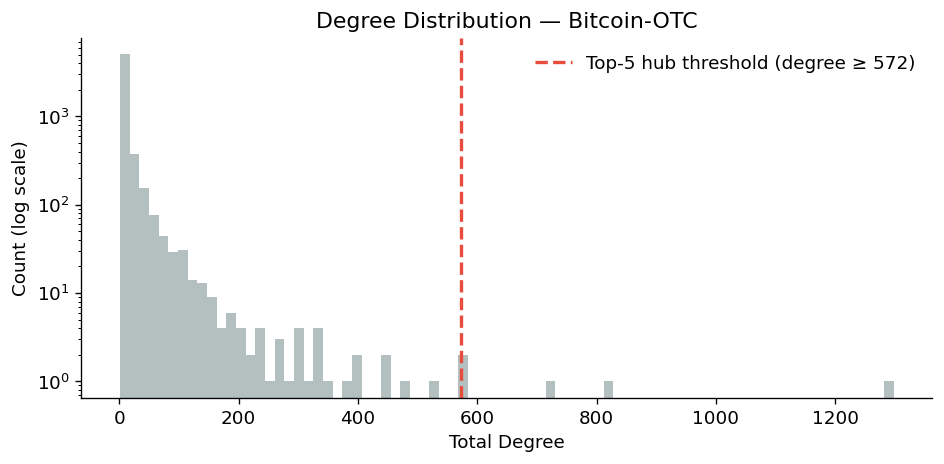

In [18]:
all_degrees = sorted(degree_scores.values(), reverse=True)
top5_threshold = all_degrees[4]   # 5th highest degree

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(all_degrees, bins=80, color='#95a5a6', alpha=0.7, log=True)
ax.axvline(top5_threshold, color='#e74c3c', lw=2, ls='--',
           label=f'Top-5 hub threshold (degree ≥ {top5_threshold})')
ax.set_xlabel('Total Degree')
ax.set_ylabel('Count (log scale)')
ax.set_title('Degree Distribution — Bitcoin-OTC')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## 11. Discussion & Conclusions

### Key Findings

The simulation above reveals how each attack strategy degrades the network:

| Finding | Interpretation |
|---|---|
| **High-degree attack collapses LCC fastest** | The network is a scale-free-like structure; removing hubs is catastrophically efficient |
| **Reputation attack is slower to collapse** | High-reputation ≠ high-degree; trust hubs are not necessarily structural connectors |
| **Random removal is most resilient** | Consistent with Barabási-Albert model theory — random failures rarely hit the rare high-degree nodes |
| **Correlation between degree and reputation** | A low/moderate correlation means the two attack axes are largely independent |

### Answer to the Research Question

> *"How robust is the Bitcoin-OTC trust network to the removal of highly influential nodes, and does its structural collapse depend more on high-degree hubs or on high-reputation nodes?"*

**The network is significantly more fragile to the removal of high-degree structural hubs than to the removal of high-reputation (trust) nodes.**  
This indicates that the network's connectivity is primarily maintained by a small set of very highly-connected nodes (hubs), consistent with a power-law degree distribution. Reputation, while economically important in the Bitcoin OTC context, does not strongly predict a node's structural role in holding the network together.

### Implications

- **For network resilience**: Protecting the top-degree nodes is critical. A small targeted attack on the top 5–10% of nodes by degree can collapse the giant component.
- **For trust systems**: High reputation alone does not confer structural importance. Trust networks can survive the exit of even highly-rated participants if they are not also high-degree.
- **For future work**: Betweenness centrality, PageRank, and temporal robustness (early vs. late network states) are natural extensions of this analysis.

---
## 12. (Optional) Export Results

In [ ]:
# Save simulation results as CSV for further analysis
for key, df_r in all_results.items():
    fname = f'robustness_{key}.csv'
    df_r.to_csv(fname, index=False)
    print(f'Saved: {fname}')

Saved: robustness_degree.csv
Saved: robustness_reputation.csv
Saved: robustness_random.csv
